#Predicting sewage levels

In [1]:
import numpy as np
import pandas as pd

import random
import os
import wandb
import math
import pprint

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score, KFold
from sklearn.feature_selection import SelectKBest, mutual_info_regression

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from scipy.stats import randint


random_state = 138
random.seed(random_state)

The paths can be configured to run locally.

In [2]:
Pluv_2022_path = 'Pluviometer data/2022.xlsx'
Pluv_2023_path = 'Pluviometer data/2023.xlsx'
Pluv_2024_path = 'Pluviometer data/2024.xlsx'

U24_2022_path = 'Sewage data/U24_2022.csv'
U24_2023_path = 'Sewage data/U24_2023.csv'
U24_2024_path = 'Sewage data/U24_2024.csv'


In [3]:
import os
print(os.getcwd())  # Zeigt den aktuellen Pfad
print(os.listdir('.'))  # Listet alle Dateien im aktuellen Ordner auf

/home/janaheitkemper/Projects/ai-project
['Pluviometer data', '.ipynb_checkpoints', 'Sewage data', 'wandb', 'tea_debug.log', 'sinakhaji5-vrije-universiteit-brussel', '.git', '.gitignore', 'README.md', 'requirements.txt', 'TAI-Sewage.ipynb']


##**Rainfall data from Flagey and Avant Port**

Removing empty columns.

In [4]:
pd_2022_df = pd.read_excel(Pluv_2022_path)
pd_2023_df = pd.read_excel(Pluv_2023_path)
pd_2024_df = pd.read_excel(Pluv_2024_path)

pd_2022_df.drop(['Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8'], axis=1, inplace=True)
pd_2022_df = pd_2022_df.rename(columns={'U24': 'P01', 'C12': 'P14'})

In [5]:
pd_merged_df = pd.concat([pd_2022_df, pd_2023_df, pd_2024_df], ignore_index=True)
pd_merged_df.columns.values

<StringArray>
['FLOWBRU - PLUVIO ALL', 'P01', 'P14']
Length: 3, dtype: str

In [6]:
pd_merged_df = pd_merged_df.rename(columns={"FLOWBRU - PLUVIO ALL":"datetime", "P01":"avant_port_mm", "P14":"flagey_mm"})

###**Data cleaning**


Initially, it was assumed that the datetime inconsistency could be
corrected through interpolation, but this assumption turned out to be incorrect.

In [7]:
for i in range(315650, 315655):
    print(f"Row {i}: {pd_merged_df.iloc[i]['datetime']}")
    print("-" * 40)

Row 315650: 2024-12-31 23:55:00
----------------------------------------
Row 315651: TOTAL
----------------------------------------
Row 315652: JAN
----------------------------------------
Row 315653: FEB
----------------------------------------
Row 315654: MAA
----------------------------------------


One of the datasets has a invalid first row.

In [8]:
print(f"Row {0}: {pd_merged_df.iloc[0]['datetime']}")

Row 0: date/time (SER UTC+1.00)


Interpolation is not appropriate here: it cannot realistically reconstruct
5-minute interval data from the totals.

Attempted datetime correction (invalid approach for this dataset)
```
pd_merged_df['datetime'] = pd.to_datetime(pd_merged_df['datetime'], errors='coerce')

for i in range(1, len(pd_merged_df)):
    if pd.isna(pd_merged_df.loc[i, 'datetime']):
        pd_merged_df.loc[i, 'datetime'] = (
            pd_merged_df.loc[i - 1, 'datetime'] + pd.Timedelta(minutes=5)
        )
```

Since the data is unreliable, we remove the affected rows instead.
Note: Removing rows by index in a loop can lead to shifting index issues, so we drop them all at once.

*errors='coerce'* makes invalid dates turn into NaN, so you can easily find and remove them later.

In [9]:
pd_merged_df['datetime'] = pd.to_datetime(pd_merged_df['datetime'], errors='coerce')
pd_merged_df['avant_port_mm'] = pd.to_numeric(pd_merged_df['avant_port_mm'], errors='coerce')
pd_merged_df['flagey_mm'] = pd.to_numeric(pd_merged_df['flagey_mm'], errors='coerce')

pre_count = pd_merged_df['datetime'].isna().sum()
pd_merged_df = pd_merged_df.dropna()
print(f"Deleted rows count: {pre_count}")

Deleted rows count: 7


/tmp/ipykernel_60809/1989009043.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd_merged_df['datetime'] = pd.to_datetime(pd_merged_df['datetime'], errors='coerce')


In [10]:
pd_merged_df['datetime']= pd.to_datetime(pd_merged_df['datetime'])
pd_merged_df['avant_port_mm'] = pd.to_numeric(pd_merged_df['avant_port_mm'])
pd_merged_df['flagey_mm'] = pd.to_numeric(pd_merged_df['flagey_mm'])

In [11]:
pd_merged_df = pd_merged_df.sort_values("datetime").reset_index(drop=True)
pd_merged_df = pd_merged_df.set_index('datetime')
pd_merged_df.head()

,avant_port_mm,flagey_mm
datetime,,
1-01-01,79.4,90.0
1-02-01,101.0,108.6
1-04-01,70.6,59.2
1-06-01,62.5,67.9
1-07-01,106.5,100.3


###**Exploratory Data Analaysis**

In [12]:
print(pd_merged_df[["avant_port_mm", "flagey_mm"]].describe())

corr = pd_merged_df["avant_port_mm"].corr(pd_merged_df["flagey_mm"])
print(f"Correlation: {corr:.3f}")

diff = (pd_merged_df["avant_port_mm"] - pd_merged_df["flagey_mm"]).abs()
print(f"Max difference: {diff.max():.4f} mm")

print(f"Null count: {pd_merged_df.isnull().sum()}")
print(f"Duplicate count: {pd_merged_df.duplicated().sum()}")

       avant_port_mm      flagey_mm
count  315657.000000  315657.000000
mean        0.010871       0.010923
std         0.472958       0.477864
min         0.000000       0.000000
25%         0.000000       0.000000
50%         0.000000       0.000000
75%         0.000000       0.000000
max       106.500000     108.600000
Correlation: 0.982
Max difference: 11.4000 mm
Null count: avant_port_mm    0
flagey_mm        0
dtype: int64
Duplicate count: 315311


Checking for unrealistic rain volume in 5-minutes intervals.

In [13]:
limit = 10
bef_count = pd_merged_df.count()

old_pd_merged_df = pd_merged_df

pd_merged_df = pd_merged_df[
    (pd_merged_df['flagey_mm'] <= limit) |
    (pd_merged_df['avant_port_mm'] <= limit)
]
print(f"Deleted rows: \n{bef_count - pd_merged_df.count()}")

Deleted rows: 
avant_port_mm    9
flagey_mm        9
dtype: int64


Checking for unrealistic 5-minutes interval differences.

In [14]:
pd_merged_df['delta_avant_port_mm'] = pd_merged_df['avant_port_mm'].diff()
pd_merged_df['delta_flagey_mm'] = pd_merged_df['flagey_mm'].diff()

In [15]:
limit = 6
bef_count = pd_merged_df.count()

pd_merged_df = pd_merged_df[
    (pd_merged_df['delta_flagey_mm'] <= limit) |
    (pd_merged_df['delta_avant_port_mm'] <= limit)
]
print(f"Deleted rows: \n{bef_count - pd_merged_df.count()}")

Deleted rows: 
avant_port_mm          1
flagey_mm              1
delta_avant_port_mm    0
delta_flagey_mm        0
dtype: int64


Data distribution after removing outliers.

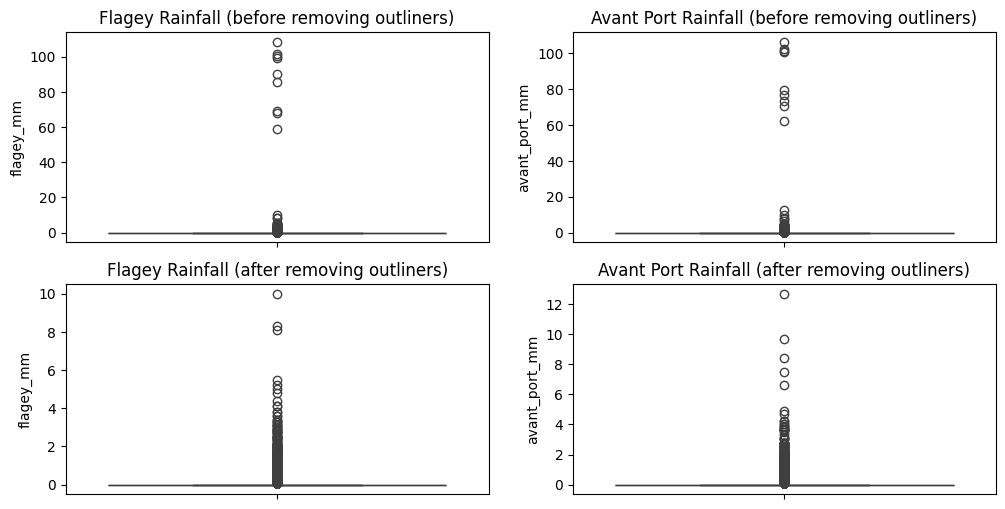

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12,6))

sns.boxplot(old_pd_merged_df['flagey_mm'], ax=axes[0,0])
axes[0,0].set_title('Flagey Rainfall (before removing outliners)')

sns.boxplot(old_pd_merged_df['avant_port_mm'], ax=axes[0,1])
axes[0,1].set_title('Avant Port Rainfall (before removing outliners)')

sns.boxplot(pd_merged_df['flagey_mm'], ax=axes[1,0])
axes[1,0].set_title('Flagey Rainfall (after removing outliners)')

sns.boxplot(pd_merged_df['avant_port_mm'], ax=axes[1,1])
axes[1,1].set_title('Avant Port Rainfall (after removing outliners)')

plt.show()

We do this because we need to use the datetime values for accurate plotting, and resetting the index makes it easier to access and work with the datetime column.

In [17]:
pd_merged_df = pd_merged_df.reset_index(drop=False)
pd_merged_df.head(1)

,datetime,avant_port_mm,flagey_mm,delta_avant_port_mm,delta_flagey_mm
0,2022-01-01 00:05:00,0.0,0.0,0.0,0.0


We are plotting rainfall volume from two sensors. We use separate charts because the data from both sensors is very similar, and combining them would make it harder to distinguish differences.

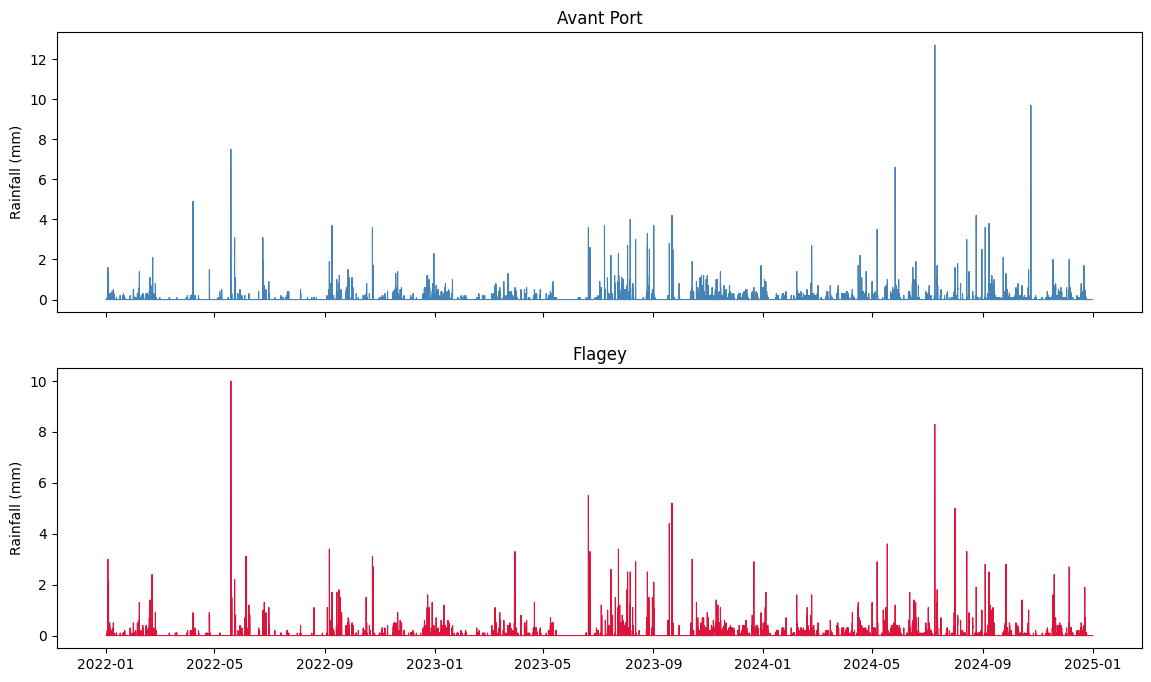

In [18]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(pd_merged_df["datetime"], pd_merged_df["avant_port_mm"], "steelblue", linewidth=0.8)
ax1.set_ylabel("Rainfall (mm)")
ax1.set_title("Avant Port")

ax2.plot(pd_merged_df["datetime"], pd_merged_df["flagey_mm"], "crimson", linewidth=0.8)
ax2.set_ylabel("Rainfall (mm)")
ax2.set_title("Flagey")

plt.show()

###**Feature Engineering / Feature Creation**

Rain volume lag 5 and 10 minutes.

In [19]:
pd_merged_df["avant_port_lag1_mm"] = pd_merged_df["avant_port_mm"].shift(1)
pd_merged_df["flagey_lag1_mm"] = pd_merged_df["flagey_mm"].shift(1)

pd_merged_df["avant_port_lag2_mm"] = pd_merged_df["avant_port_mm"].shift(2)
pd_merged_df["flagey_lag2_mm"] = pd_merged_df["flagey_mm"].shift(2)

pd_merged_df[["avant_port_lag1_mm", "avant_port_lag2_mm", "flagey_lag1_mm", "flagey_lag1_mm"]].head()

,avant_port_lag1_mm,avant_port_lag2_mm,flagey_lag1_mm,flagey_lag1_mm
0,NaN,NaN,NaN,NaN
1,0.0,NaN,0.0,0.0
2,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0


Sum of different intervals.

In [20]:
pd_merged_df["avant_port_sum_1h_mm"] = pd_merged_df["avant_port_mm"].rolling(12).sum()
pd_merged_df["flagey_sum_1h_mm"] = pd_merged_df["flagey_mm"].rolling(12).sum()

pd_merged_df["avant_port_sum_30min_mm"] = pd_merged_df["avant_port_mm"].rolling(6).sum()
pd_merged_df["flagey_sum_30min_mm"] = pd_merged_df["flagey_mm"].rolling(6).sum()

pd_merged_df["avant_port_sum_15min_mm"] = pd_merged_df["avant_port_mm"].rolling(3).sum()
pd_merged_df["flagey_sum_15min_mm"] = pd_merged_df["flagey_mm"].rolling(3).sum()

pd_merged_df[["avant_port_sum_1h_mm", "avant_port_sum_30min_mm", "avant_port_sum_15min_mm",
             "flagey_sum_1h_mm", "flagey_sum_30min_mm", "flagey_sum_15min_mm"]].tail()

,avant_port_sum_1h_mm,avant_port_sum_30min_mm,avant_port_sum_15min_mm,flagey_sum_1h_mm,flagey_sum_30min_mm,flagey_sum_15min_mm
315642,0.0,0.0,0.0,0.0,0.0,0.0
315643,0.0,0.0,0.0,0.0,0.0,0.0
315644,0.0,0.0,0.0,0.0,0.0,0.0
315645,0.0,0.0,0.0,0.0,0.0,0.0
315646,0.0,0.0,0.0,0.0,0.0,0.0


Rain intensity (per hour).

In [21]:
pd_merged_df["avant_port_intensity_15min_mm"] = pd_merged_df["avant_port_mm"].rolling(3).sum() / (15/60)
pd_merged_df["flagey_intensity_15min_mm"] = pd_merged_df["flagey_mm"].rolling(3).sum() / (15/60)

pd_merged_df["avant_port_intensity_1h_mm"] = pd_merged_df["avant_port_mm"].rolling(3).sum() / 1
pd_merged_df["flagey_intensity_1h_mm"] = pd_merged_df["flagey_mm"].rolling(3).sum() / 1

pd_merged_df["avant_port_intensity_1d_mm"] = pd_merged_df["avant_port_mm"].rolling(3).sum() / 24
pd_merged_df["flagey_intensity_1d_mm"] = pd_merged_df["flagey_mm"].rolling(3).sum() / 24

pd_merged_df[["avant_port_intensity_15min_mm", "avant_port_intensity_1h_mm", "avant_port_intensity_1d_mm",
             "flagey_intensity_15min_mm", "flagey_intensity_1h_mm", "flagey_intensity_1d_mm"]].tail()

,avant_port_intensity_15min_mm,avant_port_intensity_1h_mm,avant_port_intensity_1d_mm,flagey_intensity_15min_mm,flagey_intensity_1h_mm,flagey_intensity_1d_mm
315642,0.0,0.0,0.0,0.0,0.0,0.0
315643,0.0,0.0,0.0,0.0,0.0,0.0
315644,0.0,0.0,0.0,0.0,0.0,0.0
315645,0.0,0.0,0.0,0.0,0.0,0.0
315646,0.0,0.0,0.0,0.0,0.0,0.0


Seasons.

In [22]:
months = pd_merged_df['datetime'].dt.month

bins = [0, 3, 6, 9, 12]
labels = [0, 1, 2, 3]

pd_merged_df['season'] = pd.cut(months, bins=bins, labels=labels)

pd_merged_df[["datetime", "season"]].sample(4)

,datetime,season
295832,2024-10-24 04:45:00,3
243567,2024-04-25 17:20:00,1
95639,2022-11-29 02:00:00,3
126025,2023-03-14 14:10:00,0


In [23]:
pd_merged_df = pd_merged_df.sort_values("datetime").reset_index(drop=True)
pd_merged_df = pd_merged_df.set_index('datetime')
pd_merged_df.head(1)

,avant_port_mm,flagey_mm,delta_avant_port_mm,delta_flagey_mm,avant_port_lag1_mm,flagey_lag1_mm,avant_port_lag2_mm,flagey_lag2_mm,avant_port_sum_1h_mm,flagey_sum_1h_mm,...,flagey_sum_30min_mm,avant_port_sum_15min_mm,flagey_sum_15min_mm,avant_port_intensity_15min_mm,flagey_intensity_15min_mm,avant_port_intensity_1h_mm,flagey_intensity_1h_mm,avant_port_intensity_1d_mm,flagey_intensity_1d_mm,season
datetime,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:05:00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


##**Sewage data preprocessing**

In [24]:
sd_2022_df = pd.read_csv(U24_2022_path)
sd_2023_df = pd.read_csv(U24_2023_path)
sd_2024_df = pd.read_csv(U24_2024_path)

In [25]:
sewage_complete = pd.concat([sd_2022_df, sd_2023_df, sd_2024_df], ignore_index=True)
sewage_complete = sewage_complete.rename(columns={"Date":"datetime", "Value":"waterlevel"})
sewage_complete.head()

,datetime,waterlevel
0,2022-01-01 00:00:33,883.908
1,2022-01-01 00:01:34,881.589
2,2022-01-01 00:02:33,874.169
3,2022-01-01 00:03:33,876.719
4,2022-01-01 00:04:33,876.719


In [26]:
sewage_complete['datetime'] = pd.to_datetime(sewage_complete['datetime'], errors='coerce')
sewage_complete = sewage_complete.sort_values("datetime").reset_index(drop=True)


**Exploratory Data Analysis**

In [27]:
print("head of dataset: ")
print(sewage_complete.head())

head of dataset: 
             datetime  waterlevel
0 2022-01-01 00:00:33     883.908
1 2022-01-01 00:01:34     881.589
2 2022-01-01 00:02:33     874.169
3 2022-01-01 00:03:33     876.719
4 2022-01-01 00:04:33     876.719


In [28]:
print("tail of dataset: ")
print(sewage_complete.tail())

tail of dataset: 
                   datetime  waterlevel
1573895 2024-12-30 23:55:33    1129.401
1573896 2024-12-30 23:56:33    1121.981
1573897 2024-12-30 23:57:33    1119.663
1573898 2024-12-30 23:58:33    1117.344
1573899 2024-12-30 23:59:33    1117.344


In [29]:
print("Null values: ")
print(sewage_complete.isna().any())

Null values: 
datetime      False
waterlevel    False
dtype: bool


We have no missing values in the 'unclean' dataset, so we don't have to interpolate or remove any.

In [30]:
print("duplicated rows?")
print(sewage_complete.duplicated().any())

duplicated rows?
False


Good news, no duplicated rows either.

In [31]:
print("summary statistics")
print(sewage_complete.describe())


summary statistics
                         datetime    waterlevel
count                     1573900  1.573900e+06
mean   2023-07-02 12:05:47.054696  1.156329e+03
min           2022-01-01 00:00:33 -1.027500e+03
25%           2022-10-01 06:05:07  8.949760e+02
50%           2023-07-02 12:08:03  1.036017e+03
75%           2024-04-01 18:03:48  1.172762e+03
max           2024-12-30 23:59:33  3.738984e+03
std                           NaN  5.248455e+02


**NOTE** There are negative values in the waterlevel, which are unrealistic. We have to take care of these. Let's first check how many we have and the distribution of negative values. 

In [32]:
neg_df = sewage_complete[sewage_complete['waterlevel'] < 0]

print("amount of negative values: ", len(neg_df))

amount of negative values:  6872


In [33]:
neg_df['dateOnly'] = pd.to_datetime(neg_df['datetime']).dt.date
print(neg_df.groupby('dateOnly').size())


dateOnly
2022-06-04     754
2022-06-05    1440
2022-06-06    1440
2022-06-07    1439
2022-06-08    1440
2022-06-09     356
2023-12-19       3
dtype: int64


In 2022, we have a 5 day gap of negative values, 04-06-2022 to 05-06-2022. Since the gap is multiple days, it indicates a fault with the sensor. This data is unusable and should NOT be trained on. However, we will set the negative values to NaN for now, in order not to mess with the historical context and remove (or flag) them later after creating our input features (especially lagged water level).

For 2023, since there are only 3 negative values. These can potentially be interpolated. Let's check these further.

In [34]:
print(neg_df[pd.to_datetime(neg_df['datetime']).dt.date == pd.Timestamp('2023-12-19').date()])

                   datetime  waterlevel    dateOnly
1031731 2023-12-19 11:50:22    -1027.50  2023-12-19
1031732 2023-12-19 11:51:22    -1027.50  2023-12-19
1031733 2023-12-19 11:52:33     -203.88  2023-12-19


In [35]:
print(sewage_complete[(pd.to_datetime(sewage_complete['datetime']) > pd.to_datetime('2023-12-19 11:45')) 
    & (pd.to_datetime(sewage_complete['datetime']) < pd.to_datetime('2023-12-19 12:00'))])

                   datetime  waterlevel
1031726 2023-12-19 11:45:33    1196.877
1031727 2023-12-19 11:46:33    1208.934
1031728 2023-12-19 11:47:33    1208.934
1031729 2023-12-19 11:48:33    1211.485
1031730 2023-12-19 11:49:33    1208.934
1031731 2023-12-19 11:50:22   -1027.500
1031732 2023-12-19 11:51:22   -1027.500
1031733 2023-12-19 11:52:33    -203.880
1031734 2023-12-19 11:53:33    1216.354
1031735 2023-12-19 11:54:33    1211.485
1031736 2023-12-19 11:55:33    1208.934
1031737 2023-12-19 11:56:33    1213.804
1031738 2023-12-19 11:57:33    1211.485
1031739 2023-12-19 11:58:33    1216.354
1031740 2023-12-19 11:59:33    1211.485


In [36]:
sewage_complete.isna().any()

datetime      False
waterlevel    False
dtype: bool

Above you can see that the three negative waterlevel values are situated in subsequent timesteps (11:50-11:52). Before this, the waterlevel was 1208.934 and after, it amounted to 1216.354. Given that there is not a big change between them and also before and after the changes to waterlevel are minimal, we can use linear interpolation for these. 


In [37]:
# create a mask for the day and negative values
negative_2023_mask = ((sewage_complete['datetime'].dt.date == pd.Timestamp('2023-12-19').date())
    & (sewage_complete['waterlevel'] < 0))

# set to NaN
sewage_complete.loc[negative_2023_mask, 'waterlevel'] = np.nan

# check how many NaNs (should be 3)
print("NaNs before interpolation: ", sewage_complete['waterlevel'].isna().sum())

# interpolate
sewage_complete['waterlevel'] = sewage_complete['waterlevel'].interpolate(method='linear')

# check how many NaNs after (should be 0)
print("NaNs after interpolation: ", sewage_complete['waterlevel'].isna().sum())


NaNs before interpolation:  3
NaNs after interpolation:  0


In [38]:
print(sewage_complete[(pd.to_datetime(sewage_complete['datetime']) > pd.to_datetime('2023-12-19 11:45')) 
    & (pd.to_datetime(sewage_complete['datetime']) < pd.to_datetime('2023-12-19 12:00'))])

                   datetime  waterlevel
1031726 2023-12-19 11:45:33    1196.877
1031727 2023-12-19 11:46:33    1208.934
1031728 2023-12-19 11:47:33    1208.934
1031729 2023-12-19 11:48:33    1211.485
1031730 2023-12-19 11:49:33    1208.934
1031731 2023-12-19 11:50:22    1210.789
1031732 2023-12-19 11:51:22    1212.644
1031733 2023-12-19 11:52:33    1214.499
1031734 2023-12-19 11:53:33    1216.354
1031735 2023-12-19 11:54:33    1211.485
1031736 2023-12-19 11:55:33    1208.934
1031737 2023-12-19 11:56:33    1213.804
1031738 2023-12-19 11:57:33    1211.485
1031739 2023-12-19 11:58:33    1216.354
1031740 2023-12-19 11:59:33    1211.485


As we can see above, the negative values are interpolated and the timeseries looks reasonable now.

**Clean up faulty 5 day period**

In [39]:
sewage_complete.loc[sewage_complete['waterlevel'] < 0, 'waterlevel'] = np.nan

Now, let's have a look at how the data looks (without negative waterlevels). 

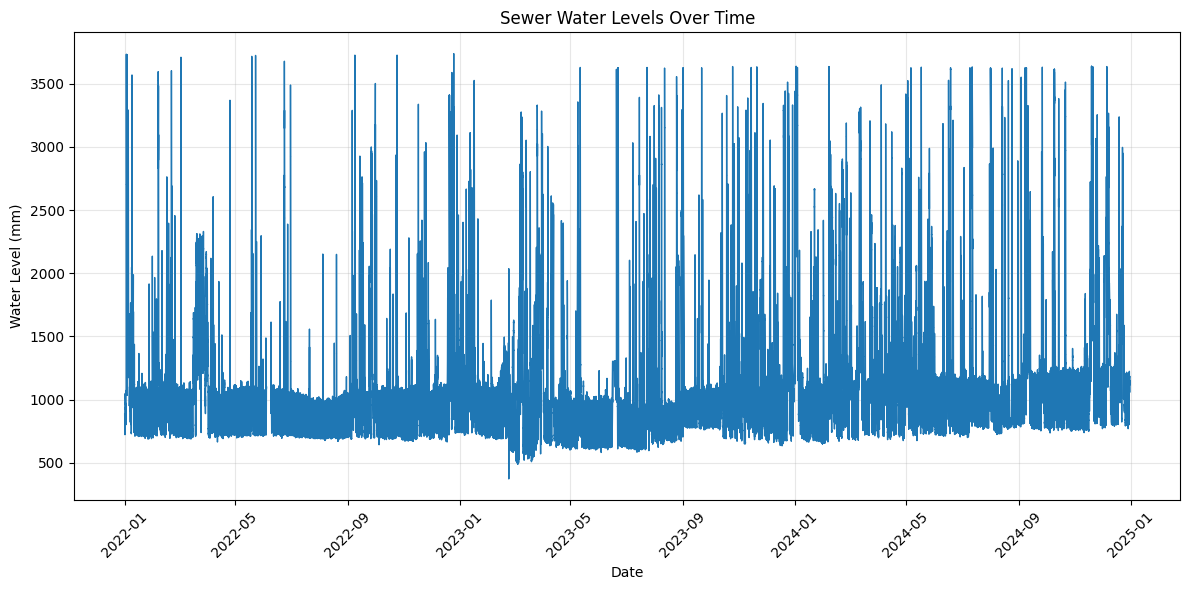

In [40]:
# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(sewage_complete['datetime'], sewage_complete['waterlevel'], linewidth=1)

# Add labels and formatting
plt.xlabel('Date')
plt.ylabel('Water Level (mm)')
plt.title('Sewer Water Levels Over Time')
plt.grid(True, alpha=0.3)

# Rotate x-axis labels for readability
plt.xticks(rotation=45)
plt.tight_layout()

# Show or save
plt.show()

From context, we know that when the level reaches 3m, an overflow event occurs. In the three years, there seems to have been quite a lot of overflow events. The waterlevel even exceeds 3.5m.

**Water level changes**

Apart from negative values, we will also check for other abnormal data, such as sudden spikes in water level that are unrealistic. For that we need the delta, aka the change of waterlevel per min.

In [41]:
sewage_complete['delta'] = sewage_complete['waterlevel'].diff()
# do not calculate delta if waterlevel is NaN
sewage_complete.loc[sewage_complete['waterlevel'].isna(), 'delta'] = np.nan

sewage_complete.head()


,datetime,waterlevel,delta
0,2022-01-01 00:00:33,883.908,NaN
1,2022-01-01 00:01:34,881.589,-2.319
2,2022-01-01 00:02:33,874.169,-7.420
3,2022-01-01 00:03:33,876.719,2.550
4,2022-01-01 00:04:33,876.719,0.000


In [42]:
sewage_complete.describe()

,datetime,waterlevel,delta
count,1573900,1.567031e+06,1.567029e+06
mean,2023-07-02 12:05:47.054696,1.165464e+03,2.707480e-04
min,2022-01-01 00:00:33,3.719270e+02,-1.606430e+03
25%,2022-10-01 06:05:07,8.975260e+02,-4.637000e+00
50%,2023-07-02 12:08:03,1.036017e+03,0.000000e+00
75%,2024-04-01 18:03:48,1.175313e+03,2.551000e+00
max,2024-12-30 23:59:33,3.738984e+03,1.601328e+03
std,NaN,5.075038e+02,8.369916e+00


In [43]:
pd_merged_df = pd_merged_df.reset_index(drop=False)

In [44]:
def plot_waterlevel_changes_and_rain(sewage, rain):
    # Create figure with 2 rows, 1 column (subplots on top of each other)
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 6))
    
    ax1.scatter(sewage['datetime'], sewage['delta'], s=1, alpha=0.5)
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Change per minute (mm)')
    ax1.set_title('Water Level Changes Over Time')
    ax1.legend()
    
    ax2.plot(sewage['datetime'], sewage["waterlevel"])
    ax2.set_ylabel("Waterlevel (mm)")
    ax2.set_title("Waterlevels")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
        
    ax3.plot(rain['datetime'], rain["avant_port_mm"], "steelblue", linewidth=0.8, label="Avant Port")
    ax3.plot(rain['datetime'], rain["flagey_mm"], "crimson", linewidth=0.8, label="Flagey")
    
    ax3.set_ylabel("Rainfall (mm)")
    ax3.set_title("Rainfall Comparison: Avant Port vs Flagey")
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    fig.subplots_adjust(hspace=0.5) 
    
    return fig

/tmp/ipykernel_60809/215694736.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_60809/215694736.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
/tmp/ipykernel_60809/2199478186.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_waterlevel_changes_and_rain(sewage_complete, pd_merged_df).show()


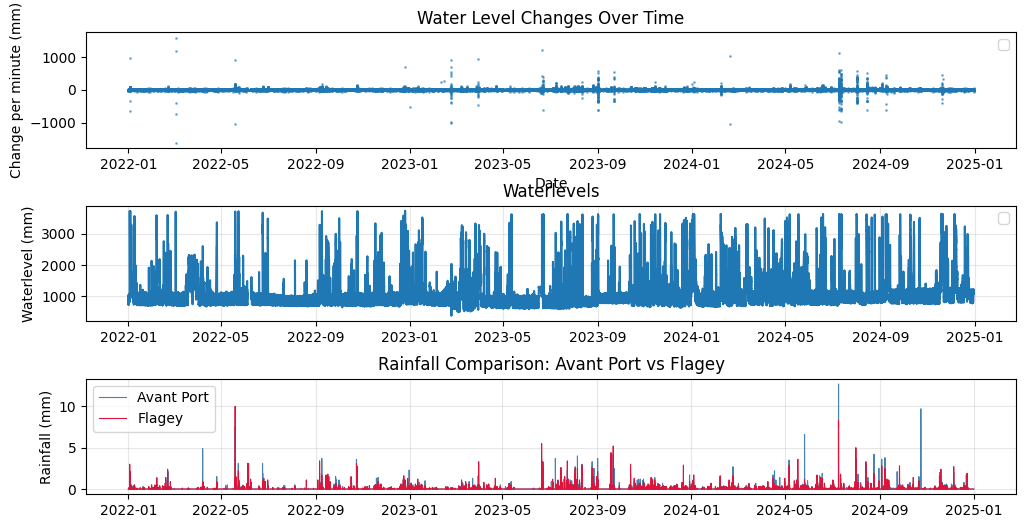

In [45]:
plot_waterlevel_changes_and_rain(sewage_complete, pd_merged_df).show()

/tmp/ipykernel_60809/3558969843.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_60809/3558969843.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


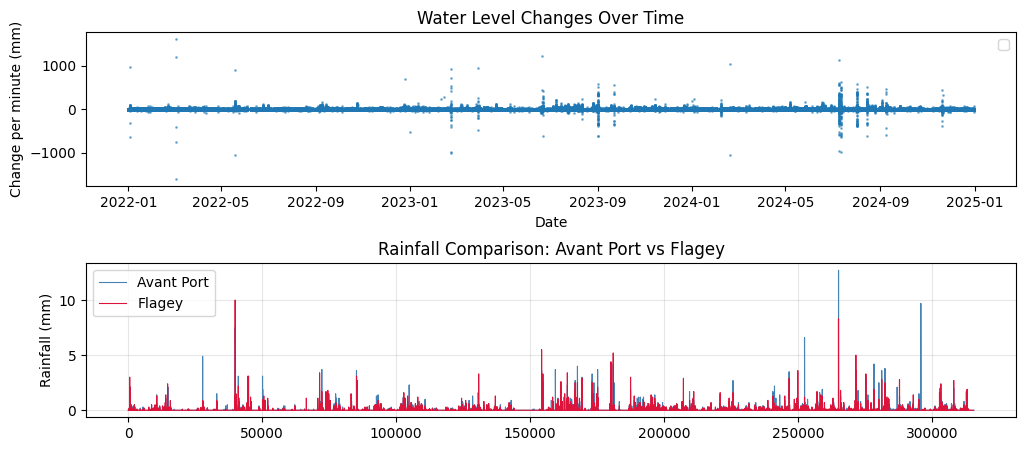

In [46]:
# Create figure with 2 rows, 1 column (subplots on top of each other)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5))

ax1.scatter(sewage_complete['datetime'], sewage_complete['delta'], s=1, alpha=0.5)
ax1.set_xlabel('Date')
ax1.set_ylabel('Change per minute (mm)')
ax1.set_title('Water Level Changes Over Time')
ax1.legend()

ax2.plot(pd_merged_df["avant_port_mm"], "steelblue", linewidth=0.8, label="Avant Port")
ax2.plot(pd_merged_df["flagey_mm"], "crimson", linewidth=0.8, label="Flagey")

ax2.set_ylabel("Rainfall (mm)")
ax2.set_title("Rainfall Comparison: Avant Port vs Flagey")
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.subplots_adjust(hspace=0.5) 

fig.show()

From the figure above, we can see that the moments where the delta has very high values of change often correspond to spikes in rainfall from either one or both of the sensors. This could generally already indicate that the sudden big changes in waterlevel are not faulty.

However, let's still have a look at the timeseries where changes are very high (above 1.5m).

In [47]:
print(f"99th percentile: {sewage_complete['delta'].quantile(0.99):.1f} mm/min")
print(f"99.9th percentile: {sewage_complete['delta'].quantile(0.999):.1f} mm/min")
print(f"Max delta: {sewage_complete['delta'].max():.1f} mm/min")

99th percentile: 14.6 mm/min
99.9th percentile: 43.6 mm/min
Max delta: 1601.3 mm/min


In [48]:
def show_timeseries_mins_around(timestamp, minutes):
    time = pd.to_datetime(timestamp)
    start = time - pd.Timedelta(minutes=minutes)
    end = time + pd.Timedelta(minutes=minutes)
    print(sewage_complete[(sewage_complete['datetime'] > pd.to_datetime(start)) &
                             (sewage_complete['datetime'] < pd.to_datetime(end))])

In [49]:
def get_timeseries_mins_around(data, timestamp, minutes):
    time = pd.to_datetime(timestamp)
    start = time - pd.Timedelta(minutes=minutes)
    end = time + pd.Timedelta(minutes=minutes)
    return (data[(data['datetime'] > pd.to_datetime(start)) &
                             (data['datetime'] < pd.to_datetime(end))])

In [50]:
# check >1.5m/min
print(">1.5m/min or <-1.5m/min")
print(sewage_complete[(sewage_complete['delta'] > 1500) | (sewage_complete['delta'] < -1500)])


>1.5m/min or <-1.5m/min
                 datetime  waterlevel     delta
88335 2022-03-03 08:15:33     3697.71  1601.328
88337 2022-03-03 08:17:33     2103.57 -1606.430


/tmp/ipykernel_60809/215694736.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_60809/215694736.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
/tmp/ipykernel_60809/1524583487.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_waterlevel_changes_and_rain(march_3_2022_sewage, march_3_2022_rain).show()


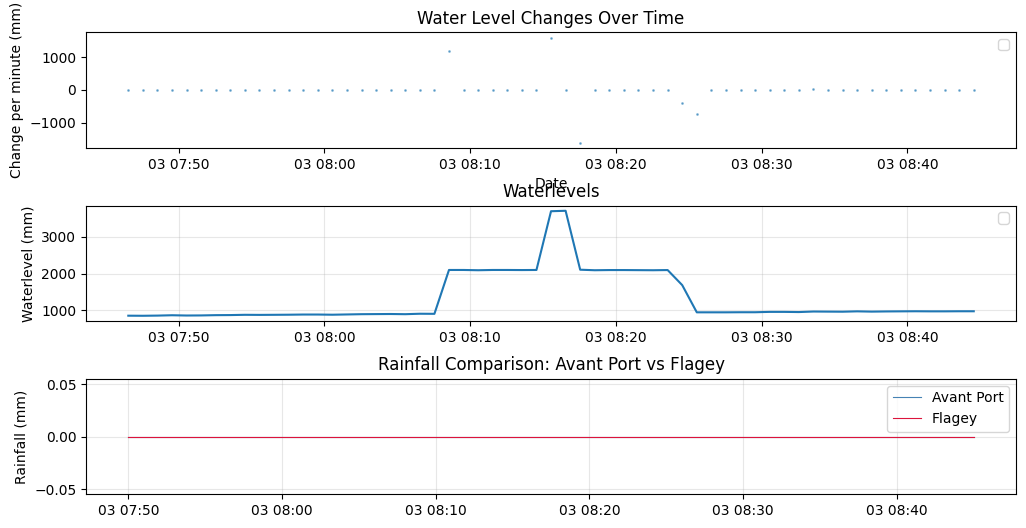

In [51]:
start_2022_03_03 = '2022-03-03 08:00'
end_2022_03_03 = '2022-03-03 08:30'
march_3_2022_sewage = get_timeseries_mins_around(sewage_complete, '2022-03-03 08:15:33', 30)
march_3_2022_rain = get_timeseries_mins_around(pd_merged_df, '2022-03-03 08:15:33', 30)


plot_waterlevel_changes_and_rain(march_3_2022_sewage, march_3_2022_rain).show()

The crazy spikes of >1.5m per minute are all on one day. Generally, this day has a lot of variation. We see that the big spikes are bringing level to exceed 3m and then to fall below 3m again. It could be realistic, considering the overflow event. 

**TO CHECK** does an overflow event mean that waterlevel falls super quickly? a meter a minute? 

TODO: check also other abnormal days

In [52]:
# check >1.5m/min
print(">1m/min or <-1m/min")
print(sewage_complete[(sewage_complete['delta'] > 1000) | (sewage_complete['delta'] < -1000)])

>1m/min or <-1m/min
                   datetime  waterlevel     delta
88328   2022-03-03 08:08:33    2096.382  1195.548
88335   2022-03-03 08:15:33    3697.710  1601.328
88337   2022-03-03 08:17:33    2103.570 -1606.430
199416  2022-05-19 11:36:33    2671.200 -1038.800
601192  2023-02-23 12:10:22    1028.829 -1007.265
770020  2023-06-20 17:58:33    2919.013  1209.924
1119357 2024-02-19 08:16:33    2008.439  1031.380
1119362 2024-02-19 08:21:33     981.929 -1053.176
1323136 2024-07-09 20:35:33    3624.376  1118.333


In [53]:
show_timeseries_mins_around('2022-05-19 11:36:33', 10)

                  datetime  waterlevel     delta
199407 2022-05-19 11:27:33    3712.319     7.188
199408 2022-05-19 11:28:33    3710.000    -2.319
199409 2022-05-19 11:29:33    3710.000     0.000
199410 2022-05-19 11:30:33    3710.000     0.000
199411 2022-05-19 11:31:33    3707.449    -2.551
199412 2022-05-19 11:32:33    3714.638     7.189
199413 2022-05-19 11:33:33    3712.319    -2.319
199414 2022-05-19 11:34:33    3707.449    -4.870
199415 2022-05-19 11:35:33    3710.000     2.551
199416 2022-05-19 11:36:33    2671.200 -1038.800
199417 2022-05-19 11:37:33    2642.216   -28.984
199418 2022-05-19 11:38:33    2637.578    -4.638
199419 2022-05-19 11:39:33    3538.413   900.835
199420 2022-05-19 11:40:33    3673.596   135.183
199421 2022-05-19 11:41:33    3707.449    33.853
199422 2022-05-19 11:42:33    3664.089   -43.360
199423 2022-05-19 11:43:33    3705.131    41.042
199424 2022-05-19 11:44:33    3710.000     4.869
199425 2022-05-19 11:45:33    3717.188     7.188


/tmp/ipykernel_60809/215694736.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_60809/215694736.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
/tmp/ipykernel_60809/1090221110.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_waterlevel_changes_and_rain(may_19_2022_sewage, may_19_2022_rain).show()


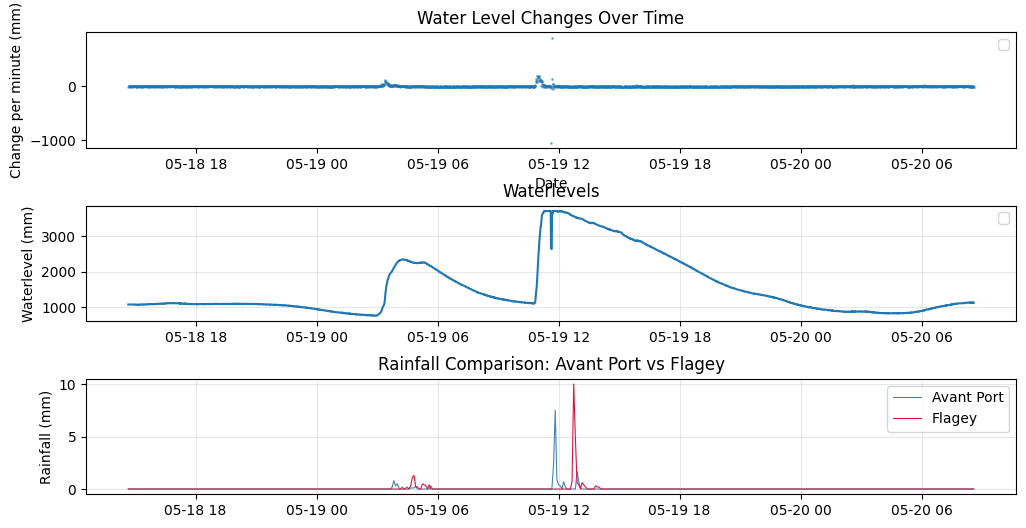

In [54]:
may_19_2022_sewage = get_timeseries_mins_around(sewage_complete, '2022-05-19 11:36:33', 1260)
may_19_2022_rain = get_timeseries_mins_around(pd_merged_df, '2022-05-19 11:36:33', 1260)
# have to unset the index of the rain one 

plot_waterlevel_changes_and_rain(may_19_2022_sewage, may_19_2022_rain).show()

Here, the fall of 1m centers happens when the waterlevel was above 3.7m, which could be explained by an overflow event, where water quickly flows out of the sewer. 

In [55]:
show_timeseries_mins_around('2023-02-23 12:10:22', 10)


                  datetime  waterlevel     delta
601183 2023-02-23 12:01:22    1997.371    -2.551
601184 2023-02-23 12:02:22    1818.596  -178.775
601185 2023-02-23 12:03:22    1577.214  -241.382
601186 2023-02-23 12:04:22    2002.241   425.027
601187 2023-02-23 12:05:22    1026.511  -975.730
601188 2023-02-23 12:06:22    1021.641    -4.870
601189 2023-02-23 12:07:22    1021.641     0.000
601190 2023-02-23 12:08:22    1113.464    91.823
601191 2023-02-23 12:09:22    2036.094   922.630
601192 2023-02-23 12:10:22    1028.829 -1007.265
601193 2023-02-23 12:11:22    1021.641    -7.188
601194 2023-02-23 12:12:22    1021.641     0.000
601195 2023-02-23 12:13:22    1021.641     0.000
601196 2023-02-23 12:14:22    1026.511     4.870
601197 2023-02-23 12:15:22    1026.511     0.000
601198 2023-02-23 12:16:22    1023.960    -2.551
601199 2023-02-23 12:17:22    1023.960     0.000
601200 2023-02-23 12:18:22    1021.641    -2.319
601201 2023-02-23 12:19:22    1019.091    -2.550


/tmp/ipykernel_60809/215694736.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_60809/215694736.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
/tmp/ipykernel_60809/2806670606.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_waterlevel_changes_and_rain(feb_2_2023_sewage, feb_2_2023_rain).show()


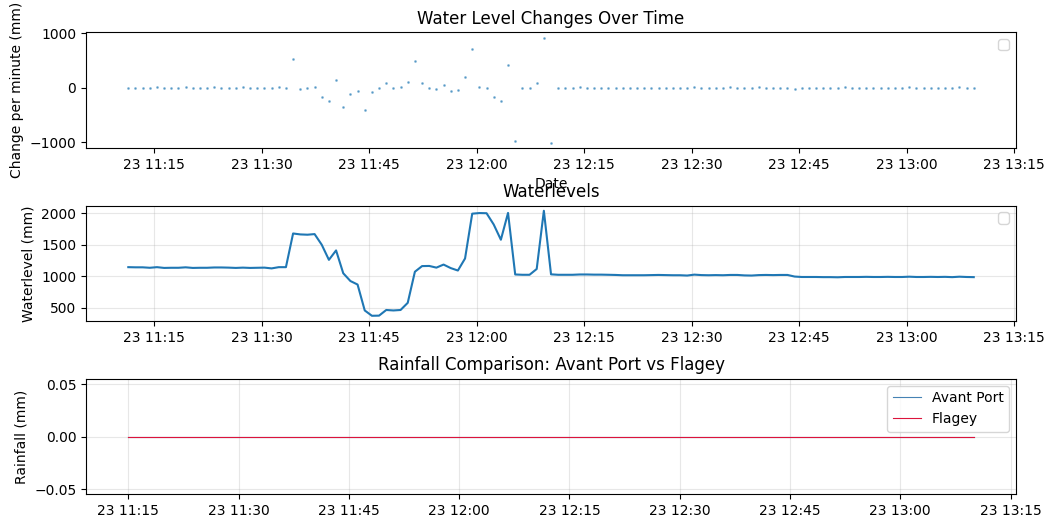

In [56]:
feb_2_2023_sewage = get_timeseries_mins_around(sewage_complete, '2023-02-23 12:10:22', 60)
feb_2_2023_rain = get_timeseries_mins_around(pd_merged_df, '2023-02-23 12:10:22', 60)
# have to unset the index of the rain one 

plot_waterlevel_changes_and_rain(feb_2_2023_sewage, feb_2_2023_rain).show()

**NOTE** here it does NOT center around an overflow event. Can waterlevel fall 1m in a minute without an overflow event? 

In [57]:
show_timeseries_mins_around('2023-06-20 17:58:33', 10)


                  datetime  waterlevel     delta
770011 2023-06-20 17:49:33    1163.023    -4.869
770012 2023-06-20 17:50:33    1163.023     0.000
770013 2023-06-20 17:51:33    1165.574     2.551
770014 2023-06-20 17:52:33    1170.443     4.869
770015 2023-06-20 17:53:33    1170.443     0.000
770016 2023-06-20 17:54:33    1153.516   -16.927
770017 2023-06-20 17:55:33    1310.496   156.980
770018 2023-06-20 17:56:33    1269.454   -41.042
770019 2023-06-20 17:57:33    1709.089   439.635
770020 2023-06-20 17:58:33    2919.013  1209.924
770021 2023-06-20 17:59:33    2996.459    77.446
770022 2023-06-20 18:00:33    3056.746    60.287
770023 2023-06-20 18:01:33    3107.527    50.781
770024 2023-06-20 18:02:33    3162.945    55.418
770025 2023-06-20 18:03:33    3230.653    67.708
770026 2023-06-20 18:04:33    3271.695    41.042
770027 2023-06-20 18:05:33    3298.360    26.665
770028 2023-06-20 18:06:33    3339.402    41.042
770029 2023-06-20 18:07:33    3375.574    36.172


In [58]:
show_timeseries_mins_around('2024-02-19 08:16:33', 10)
show_timeseries_mins_around('2024-02-19 08:21:33', 10)

                   datetime  waterlevel     delta
1119348 2024-02-19 08:07:33     957.814     0.000
1119349 2024-02-19 08:08:33     960.132     2.318
1119350 2024-02-19 08:09:33     957.814    -2.318
1119351 2024-02-19 08:10:33     967.552     9.738
1119352 2024-02-19 08:11:33     969.871     2.319
1119353 2024-02-19 08:12:33     969.871     0.000
1119354 2024-02-19 08:13:33     974.741     4.870
1119355 2024-02-19 08:14:33     967.552    -7.189
1119356 2024-02-19 08:15:33     977.059     9.507
1119357 2024-02-19 08:16:33    2008.439  1031.380
1119358 2024-02-19 08:17:33    2042.293    33.854
1119359 2024-02-19 08:18:33    2037.424    -4.869
1119360 2024-02-19 08:19:33    2037.424     0.000
1119361 2024-02-19 08:20:33    2035.105    -2.319
1119362 2024-02-19 08:21:33     981.929 -1053.176
1119363 2024-02-19 08:22:33     981.929     0.000
1119364 2024-02-19 08:23:33     986.798     4.869
1119365 2024-02-19 08:24:34     991.668     4.870
1119366 2024-02-19 08:25:33     984.479    -7.189


In [59]:

show_timeseries_mins_around('2024-07-09 20:35:33', 10)

                   datetime  waterlevel     delta
1323127 2024-07-09 20:26:33    2592.996  -280.105
1323128 2024-07-09 20:27:33    2576.070   -16.926
1323129 2024-07-09 20:28:33    2571.200    -4.870
1323130 2024-07-09 20:29:33    2556.824   -14.376
1323131 2024-07-09 20:30:33    2551.954    -4.870
1323132 2024-07-09 20:31:33    2547.085    -4.869
1323133 2024-07-09 20:32:33    2542.216    -4.869
1323134 2024-07-09 20:33:33    2522.970   -19.246
1323135 2024-07-09 20:34:33    2506.043   -16.927
1323136 2024-07-09 20:35:33    3624.376  1118.333
1323137 2024-07-09 20:36:33    3624.376     0.000
1323138 2024-07-09 20:37:33    3619.507    -4.869
1323139 2024-07-09 20:38:33    3622.058     2.551
1323140 2024-07-09 20:39:33    3617.188    -4.870
1323141 2024-07-09 20:40:33    3626.695     9.507
1323142 2024-07-09 20:41:33    3614.638   -12.057
1323143 2024-07-09 20:42:33    3622.058     7.420
1323144 2024-07-09 20:43:33    3622.058     0.000
1323145 2024-07-09 20:44:33    3617.188    -4.870


In [60]:
print("number of NaNs: ", sewage_complete['waterlevel'].isna().sum())
print("% of NaNs: ", sewage_complete['waterlevel'].isna().sum()/len(sewage_complete) * 100)

number of NaNs:  6869
% of NaNs:  0.43643179363364887


Now we see that we have 0.43% of the data that is NaN. We have to see what to do with that data.

## Downsampling
We need to downsample to 5 mins in order to match the other rainfall dataset. We can use the mean, max or median here (median is more robust to outliers). Alternatively, we could keep multiple columns and see which one works better in our models.

In [61]:
sewage_5min_mean = sewage_complete.resample('5min', on='datetime').mean().reset_index()
sewage_5min_max = sewage_complete.resample('5min', on='datetime').max().reset_index()


print(sewage_5min_mean.head())
print(sewage_5min_max.head())


             datetime  waterlevel    delta
0 2022-01-01 00:00:00    878.6208 -1.79725
1 2022-01-01 00:05:00    875.7454 -1.43760
2 2022-01-01 00:10:00    875.2354 -0.97380
3 2022-01-01 00:15:00    869.4848  0.97380
4 2022-01-01 00:20:00    874.2152  0.92760
             datetime  waterlevel   delta
0 2022-01-01 00:00:00     883.908   2.550
1 2022-01-01 00:05:00     881.589   4.870
2 2022-01-01 00:10:00     881.589  12.058
3 2022-01-01 00:15:00     871.850   7.188
4 2022-01-01 00:20:00     876.719   4.638


/tmp/ipykernel_60809/1270680806.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


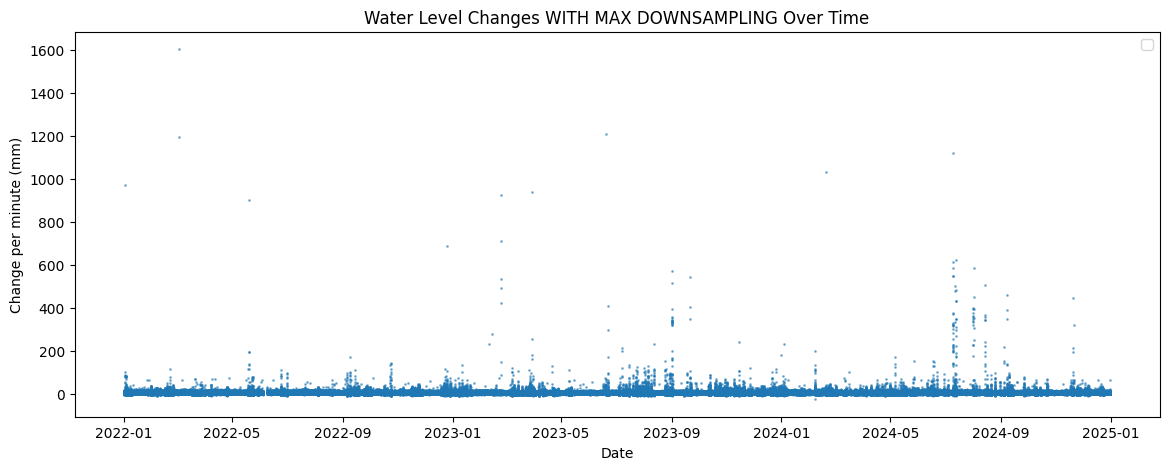

In [62]:
plt.figure(figsize=(14, 5))
plt.scatter(sewage_5min_max['datetime'], sewage_5min_max['delta'], s=1, alpha=0.5)
plt.xlabel('Date')
plt.ylabel('Change per minute (mm)')
plt.title('Water Level Changes WITH MAX DOWNSAMPLING Over Time')
plt.legend()
plt.show()

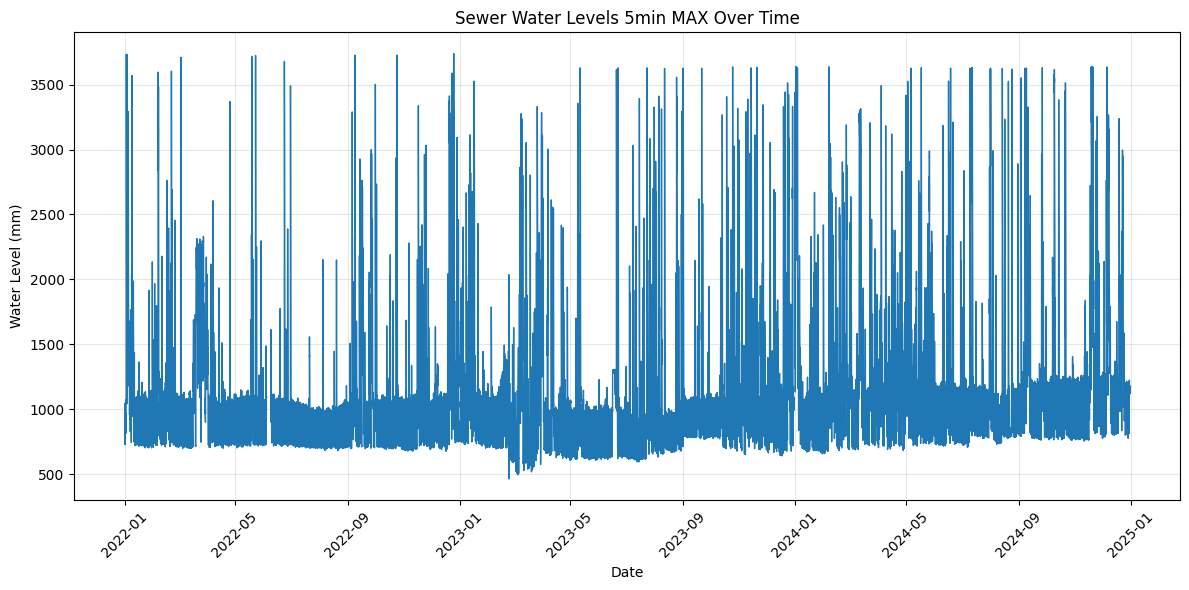

In [63]:
# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(sewage_5min_max['datetime'], sewage_5min_max['waterlevel'], linewidth=1)

# Add labels and formatting
plt.xlabel('Date')
plt.ylabel('Water Level (mm)')
plt.title('Sewer Water Levels 5min MAX Over Time')
plt.grid(True, alpha=0.3)

# Rotate x-axis labels for readability
plt.xticks(rotation=45)
plt.tight_layout()

# Show or save
plt.show()

/tmp/ipykernel_60809/3496371744.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


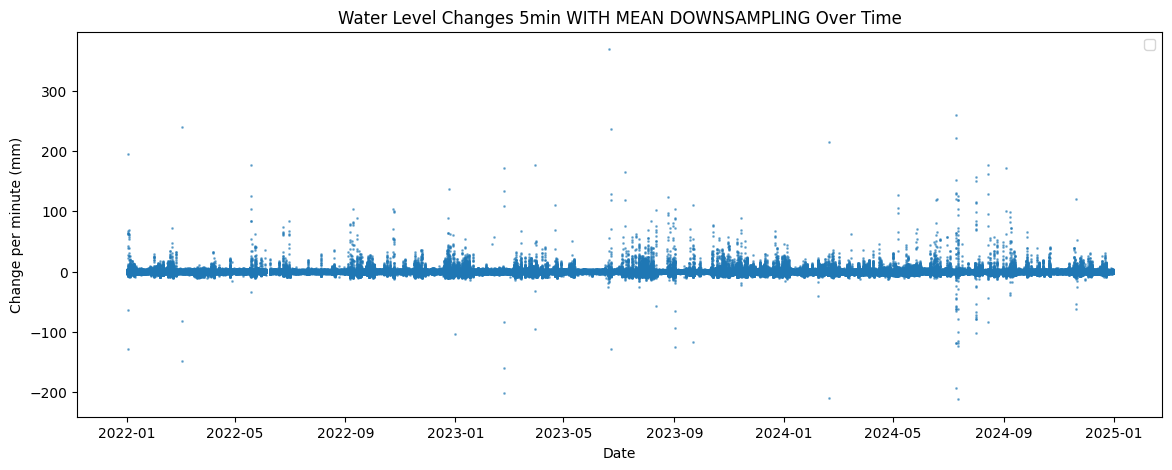

In [64]:
plt.figure(figsize=(14, 5))
plt.scatter(sewage_5min_mean['datetime'], sewage_5min_mean['delta'], s=1, alpha=0.5)
plt.xlabel('Date')
plt.ylabel('Change per minute (mm)')
plt.title('Water Level Changes 5min WITH MEAN DOWNSAMPLING Over Time')
plt.legend()
plt.show()

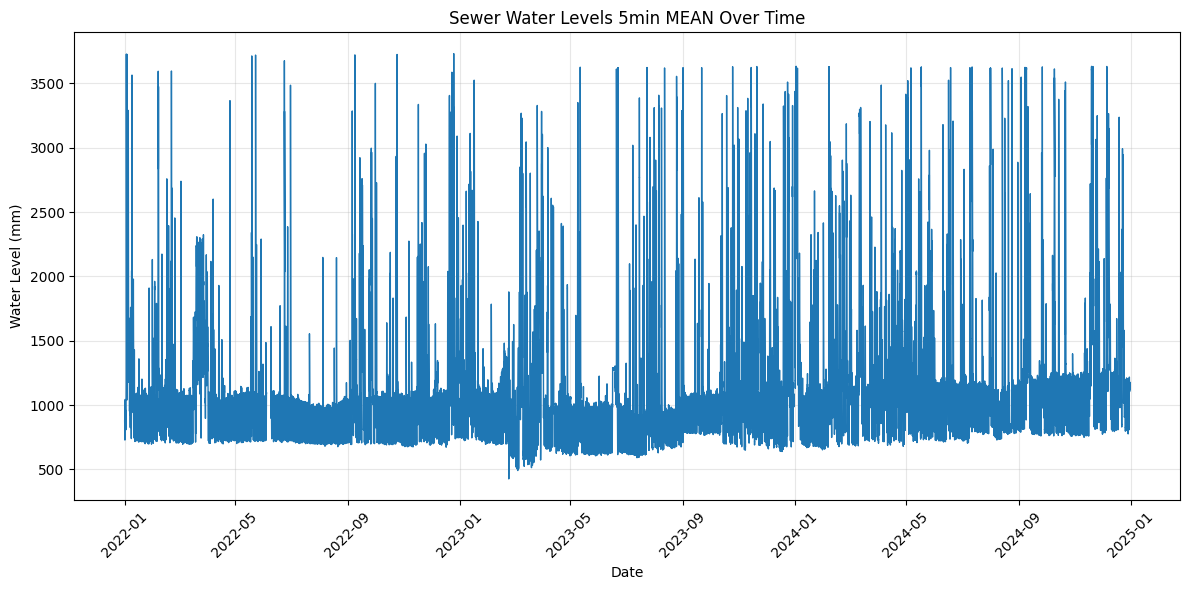

In [65]:
# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(sewage_5min_mean['datetime'], sewage_5min_mean['waterlevel'], linewidth=1)

# Add labels and formatting
plt.xlabel('Date')
plt.ylabel('Water Level (mm)')
plt.title('Sewer Water Levels 5min MEAN Over Time')
plt.grid(True, alpha=0.3)

# Rotate x-axis labels for readability
plt.xticks(rotation=45)
plt.tight_layout()

# Show or save
plt.show()

For the sake of the models, for now we keep the "mean" downsampling. Later, we can experiment also with the max and see how it affects model performance.

#Feature Engineering

We want to make the following features:
* lagged waterlevel (t-1, t-2, etc.)
* water level rate of change (already done)
* distance to threshold (3000-waterlevel at time t)


In [66]:
sewage_5min_mean['waterlevel_lag_1'] = sewage_5min_mean['waterlevel'].shift(1)
sewage_5min_mean['waterlevel_lag_2'] = sewage_5min_mean['waterlevel'].shift(2)
sewage_5min_mean['waterlevel_lag_3'] = sewage_5min_mean['waterlevel'].shift(3)
sewage_5min_mean['threshold_distance'] = 3000 - sewage_5min_mean['waterlevel']
sewage_5min_mean.head()

,datetime,waterlevel,delta,waterlevel_lag_1,waterlevel_lag_2,waterlevel_lag_3,threshold_distance
0,2022-01-01 00:00:00,878.6208,-1.79725,NaN,NaN,NaN,2121.3792
1,2022-01-01 00:05:00,875.7454,-1.43760,878.6208,NaN,NaN,2124.2546
2,2022-01-01 00:10:00,875.2354,-0.97380,875.7454,878.6208,NaN,2124.7646
3,2022-01-01 00:15:00,869.4848,0.97380,875.2354,875.7454,878.6208,2130.5152
4,2022-01-01 00:20:00,874.2152,0.92760,869.4848,875.2354,875.7454,2125.7848


In [67]:
sewage_5min_mean = sewage_5min_mean.set_index('datetime')


In [68]:
print(sewage_5min_mean.head())

                     waterlevel    delta  waterlevel_lag_1  waterlevel_lag_2  \
datetime                                                                       
2022-01-01 00:00:00    878.6208 -1.79725               NaN               NaN   
2022-01-01 00:05:00    875.7454 -1.43760          878.6208               NaN   
2022-01-01 00:10:00    875.2354 -0.97380          875.7454          878.6208   
2022-01-01 00:15:00    869.4848  0.97380          875.2354          875.7454   
2022-01-01 00:20:00    874.2152  0.92760          869.4848          875.2354   

                     waterlevel_lag_3  threshold_distance  
datetime                                                   
2022-01-01 00:00:00               NaN           2121.3792  
2022-01-01 00:05:00               NaN           2124.2546  
2022-01-01 00:10:00               NaN           2124.7646  
2022-01-01 00:15:00          878.6208           2130.5152  
2022-01-01 00:20:00          875.7454           2125.7848  


In [69]:
sewage_5min_mean.isna().sum()

waterlevel            1949
delta                 1949
waterlevel_lag_1      1950
waterlevel_lag_2      1951
waterlevel_lag_3      1952
threshold_distance    1949
dtype: int64

#Merging Datasets

In [70]:
pd_merged_df = pd_merged_df.set_index('datetime')
sewage_rainfall_df = pd_merged_df.join(sewage_5min_mean, how='inner')

In [71]:
sewage_rainfall_df.head()

,avant_port_mm,flagey_mm,delta_avant_port_mm,delta_flagey_mm,avant_port_lag1_mm,flagey_lag1_mm,avant_port_lag2_mm,flagey_lag2_mm,avant_port_sum_1h_mm,flagey_sum_1h_mm,...,flagey_intensity_1h_mm,avant_port_intensity_1d_mm,flagey_intensity_1d_mm,season,waterlevel,delta,waterlevel_lag_1,waterlevel_lag_2,waterlevel_lag_3,threshold_distance
datetime,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:05:00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,875.7454,-1.4376,878.6208,NaN,NaN,2124.2546
2022-01-01 00:10:00,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,875.2354,-0.9738,875.7454,878.6208,NaN,2124.7646
2022-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,...,0.0,0.0,0.0,0,869.4848,0.9738,875.2354,875.7454,878.6208,2130.5152
2022-01-01 00:20:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,...,0.0,0.0,0.0,0,874.2152,0.9276,869.4848,875.2354,875.7454,2125.7848
2022-01-01 00:25:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,...,0.0,0.0,0.0,0,869.9486,-0.4638,874.2152,869.4848,875.2354,2130.0514


Let's remove the rows with NaN

In [72]:
sewage_rainfall_df.describe()

,avant_port_mm,flagey_mm,delta_avant_port_mm,delta_flagey_mm,avant_port_lag1_mm,flagey_lag1_mm,avant_port_lag2_mm,flagey_lag2_mm,avant_port_sum_1h_mm,flagey_sum_1h_mm,...,avant_port_intensity_1h_mm,flagey_intensity_1h_mm,avant_port_intensity_1d_mm,flagey_intensity_1d_mm,waterlevel,delta,waterlevel_lag_1,waterlevel_lag_2,waterlevel_lag_3,threshold_distance
count,315359.000000,315359.000000,3.153590e+05,3.153590e+05,315358.000000,315358.000000,315357.000000,315357.000000,315348.000000,315348.000000,...,315357.000000,315357.000000,315357.000000,315357.000000,313410.000000,313410.000000,313410.000000,313409.000000,313408.000000,313410.000000
mean,0.008427,0.008454,-1.408202e-20,1.434606e-20,0.008427,0.008454,0.008427,0.008454,0.101130,0.101454,...,0.025282,0.025363,0.001053,0.001057,1165.463035,0.000293,1165.462261,1165.462410,1165.462542,1834.536965
std,0.076177,0.073524,7.147585e-02,6.253837e-02,0.076177,0.073524,0.076177,0.073524,0.551848,0.550307,...,0.186656,0.186361,0.007777,0.007765,507.448982,4.003953,507.449234,507.450037,507.450841,507.448982
min,0.000000,0.000000,-1.010000e+01,-5.200000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,426.000600,-211.562800,426.000600,426.000600,426.000600,-731.100400
25%,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,897.989800,-1.437600,897.989800,897.989800,897.985500,1825.754000
50%,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1037.037600,0.000000,1037.037600,1037.037600,1037.037600,1962.962400
75%,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1174.246000,0.973800,1174.246000,1174.246000,1174.249750,2102.010200
max,12.700000,10.000000,1.270000e+01,9.300000e+00,12.700000,10.000000,12.700000,10.000000,21.800000,20.200000,...,16.000000,20.200000,0.666667,0.841667,3731.100400,368.588600,3731.100400,3731.100400,3731.100400,2573.999400


Here we set the target (the data that needs to be predicted) - 60min/1hour (12*5) prediction.

In [73]:
sewage_rainfall_df['target'] = sewage_rainfall_df['waterlevel'].shift(-12)

print(sewage_rainfall_df['target'].head())
print(sewage_rainfall_df['waterlevel'].head())

datetime
2022-01-01 00:05:00    852.5116
2022-01-01 00:10:00    852.0016
2022-01-01 00:15:00    853.9954
2022-01-01 00:20:00    850.1002
2022-01-01 00:25:00    850.1000
Name: target, dtype: float64
datetime
2022-01-01 00:05:00    875.7454
2022-01-01 00:10:00    875.2354
2022-01-01 00:15:00    869.4848
2022-01-01 00:20:00    874.2152
2022-01-01 00:25:00    869.9486
Name: waterlevel, dtype: float64


We remove the rows for which we cannot have a target.

In [74]:
print(sewage_rainfall_df.isna().sum()['target'])
sewage_rainfall_df = sewage_rainfall_df.dropna()
print(sewage_rainfall_df.isna().sum()['target'])

1961
0


We split the dataset into training/validation and test sets while respecting the time order, since this is time series data and shuffling would break the temporal structure. The most recent 20% of the data is kept as the test set, and the remaining 80% is used for training and validation. Furthermore, it will be split into a train and validation set that will only be useful later for the other two models. For the sweep config, it is not needed since the validation process is taking place in the train_val set. 

In [75]:
df_train_val, df_test = train_test_split(sewage_rainfall_df, test_size=0.2, shuffle=False)

In [76]:
X_train_val = df_train_val.drop(columns=['target'])
y_train_val = df_train_val['target']

X_test = df_test.drop(columns=['target'])
y_test = df_test['target']

In [77]:
# make a distinguished train and val set for the other models
df_train, df_val = train_test_split(df_train_val, test_size=0.25, shuffle=False)
X_train = df_train.drop(columns=['target'])
y_train = df_train['target']
X_val = df_val.drop(columns=['target'])
y_val = df_val['target']

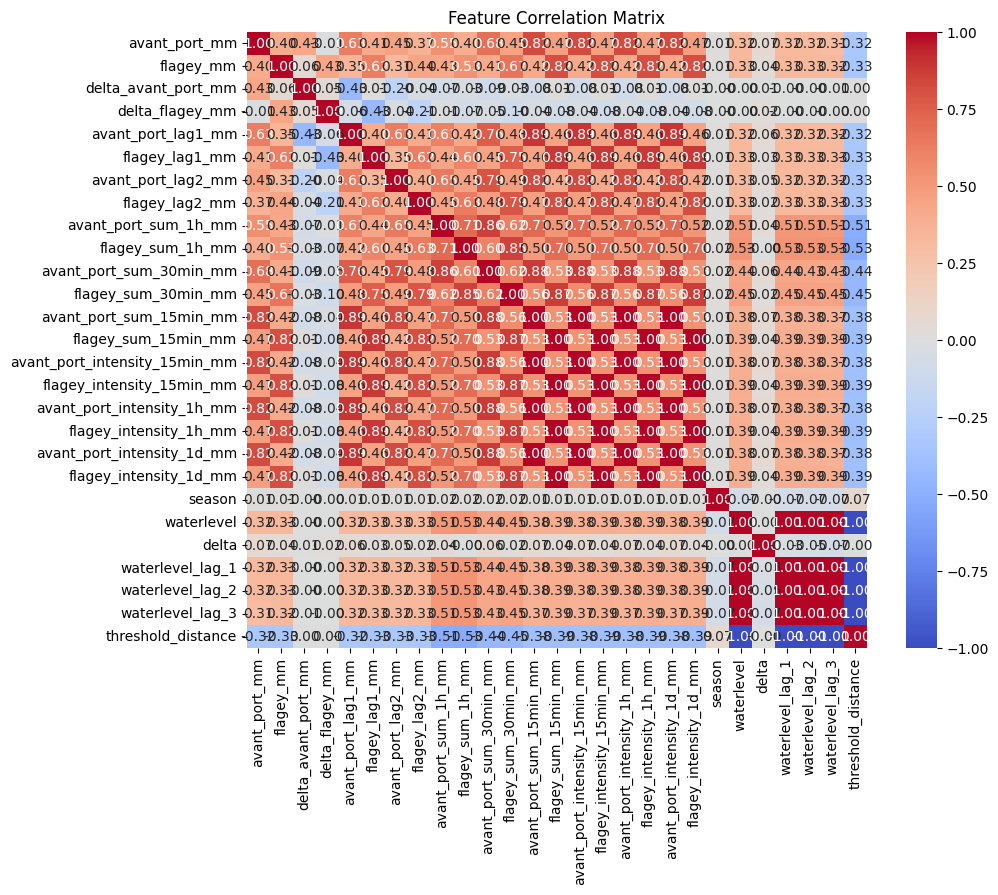

In [78]:
corr_matrix = X_train_val.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Feature Correlation Matrix")
plt.show()

Select top 10 features using mutual information for regression.

In [79]:
selector = SelectKBest(score_func=mutual_info_regression, k=10)
selector.fit(X_train_val, y_train_val)

selected_features = X_train_val.columns[selector.get_support()]
print('Selected features (SelectKBest): \n', selected_features.tolist())

Selected features (SelectKBest): 
 ['avant_port_sum_1h_mm', 'flagey_sum_1h_mm', 'flagey_sum_30min_mm', 'season', 'waterlevel', 'delta', 'waterlevel_lag_1', 'waterlevel_lag_2', 'waterlevel_lag_3', 'threshold_distance']


In [80]:
def compute_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        "mse": mse,
        "rmse": np.sqrt(mse),
        "mae": mae,
        "r2": r2
    }

In [81]:
def log_split_metrics(run, prefix, y_true, y_pred, step=None):
    metrics = compute_metrics(y_true, y_pred)
    metrics = {f"{prefix}/{k}": v for k, v in metrics.items()}
    run.log(metrics, step=step)

In [82]:
os.environ["WANDB_SILENT"] = "true"

In [83]:
wandb.login("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")

True

This config defines a hyperparameter sweep to optimize a model by maximizing cv/accuracy_mean. It searches over different network sizes, learning rates, batch sizes, activation functions, regularization strength, and solvers using Bayesian optimization, while keeping some training settings fixed (early stopping, validation split, and iteration limits).

In [84]:
sweep_config = {
    "method": "bayes",  # or "random"
    "metric": {
        "name": "cv/accuracy_mean",  # must match what you log
        "goal": "maximize"
    },
    "parameters": {
        "hidden_layer_sizes": {
            "values": [
                (16,),
                (32,),
                (64,),
                (128,),
                (32, 16),
                (64, 32),
                (128, 64),
                (64, 32, 16)
            ]
        },

        "learning_rate_init": {
            "distribution": "log_uniform_values",
            "min": 1e-5,
            "max": 5e-2
        },

        "batch_size": {
            "values": [16, 32, 64, 128, 256]
        },

        "activation": {
            "values": ["relu", "tanh", "logistic"]
        },

        "alpha": {
            "distribution": "log_uniform_values",
            "min": 1e-6,
            "max": 1e-2
        },

        "solver": {
            "values": ["adam", "sgd"]
        },

        # Fixed parameters
        "early_stopping": {"value": True},
        "validation_fraction": {"value": 0.1},
        "max_iter": {"value": 80},
        "n_iter_no_change": {"value": 10}
    }
}

In [85]:
pprint.pprint(sweep_config)

{'method': 'bayes',
 'metric': {'goal': 'maximize', 'name': 'cv/accuracy_mean'},
 'parameters': {'activation': {'values': ['relu', 'tanh', 'logistic']},
                'alpha': {'distribution': 'log_uniform_values',
                          'max': 0.01,
                          'min': 1e-06},
                'batch_size': {'values': [16, 32, 64, 128, 256]},
                'early_stopping': {'value': True},
                'hidden_layer_sizes': {'values': [(16,),
                                                  (32,),
                                                  (64,),
                                                  (128,),
                                                  (32, 16),
                                                  (64, 32),
                                                  (128, 64),
                                                  (64, 32, 16)]},
                'learning_rate_init': {'distribution': 'log_uniform_values',
                                 

In [86]:
sweep_id = wandb.sweep(sweep_config, project="ann-cv")

Create sweep with ID: gv7zm559
Sweep URL: https://wandb.ai/sinakhaji5-vrije-universiteit-brussel/ann-cv/sweeps/gv7zm559


In [87]:
entity = "sinakhaji5-vrije-universiteit-brussel"
project = "ann-cv"
sweep_id = sweep_id

In [88]:
def sweep_train_cv(project, X_train_val, y_train_val, random_state, n_splits=5):
    with wandb.init(project=project) as run:
        raw_cfg = dict(run.config)

        # Filter valid params
        valid_params = MLPRegressor().get_params().keys()
        cfg = {k: v for k, v in raw_cfg.items() if k in valid_params}

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("ann", MLPRegressor(**cfg)),
        ])

        cv = KFold(n_splits=n_splits, shuffle=False)
        scores = cross_val_score(
            model, X_train_val, y_train_val,
            cv=cv, scoring="r2", n_jobs=-1
        )

        run.log({
            "cv/accuracy_mean": float(scores.mean()),
            "cv/accuracy_std": float(scores.std()),
        })

In [89]:
wandb.agent(
    sweep_id,
    function=lambda: sweep_train_cv(
        project = project,
        X_train_val=X_train_val,
        y_train_val=y_train_val,
        random_state=random_state
    ),
    count=1
)

In [90]:
def retrain_best_and_test(entity, project, sweep_id, X_train_val, y_train_val, X_test, y_test):
    api = wandb.Api()
    sweep = api.sweep(f"{entity}/{project}/{sweep_id}")

    best = sweep.best_run(order="cv/accuracy_mean").load_full_data()

    raw_cfg = dict(best["rawconfig"])

    valid_params = MLPRegressor().get_params().keys()
    cfg = {k: v for k, v in raw_cfg.items() if k in valid_params}

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("ann", MLPRegressor(**cfg))
    ])

    pipe.fit(X_train_val, y_train_val)

    y_pred = pipe.predict(X_test)

    test_acc = compute_metrics(y_test, y_pred)

    print("Best run:", best["displayName"], "| test R2:", test_acc['r2'])

    return pipe, cfg, test_acc

In [91]:
pipe, best_hparams, test_acc = retrain_best_and_test(
    entity=entity,
    project=project,
    sweep_id=sweep_id,
    X_train_val=X_train_val,
    y_train_val=y_train_val,
    X_test=X_test,
    y_test=y_test,
)

print("Best hyperparameters found by the sweep:")
pprint.pprint(best_hparams)

Best run: ancient-sweep-1 | test R2: -0.03960173453471527
Best hyperparameters found by the sweep:
{'activation': 'logistic',
 'alpha': 0.0013079485442164503,
 'batch_size': 256,
 'early_stopping': True,
 'hidden_layer_sizes': [32, 16],
 'learning_rate_init': 0.0005161879871209632,
 'max_iter': 80,
 'n_iter_no_change': 10,
 'solver': 'sgd',
 'validation_fraction': 0.1}


In [92]:
test_acc

{'mse': 287094.4109802835,
 'rmse': np.float64(535.8119175422319),
 'mae': 290.2351528068527,
 'r2': -0.03960173453471527}

In [93]:
api = wandb.Api()
sweep = api.sweep(f"{entity}/{project}/{sweep_id}")
sweep.best_run(order="val/accuracy").name

'ancient-sweep-1'

**Feature importance using RandomForestRegressor**

Since for the next, we don't use wandb and sweeping, we will split the trainval further into train and validation set. 

Top 10 features by importance:
1. threshold_distance (0.6324)
2. waterlevel (0.2734)
3. delta (0.0504)
4. waterlevel_lag_3 (0.0146)
5. waterlevel_lag_2 (0.0075)
6. waterlevel_lag_1 (0.0071)
7. season (0.0037)
8. avant_port_sum_1h_mm (0.0022)
9. flagey_sum_1h_mm (0.0019)
10. avant_port_sum_30min_mm (0.0016)


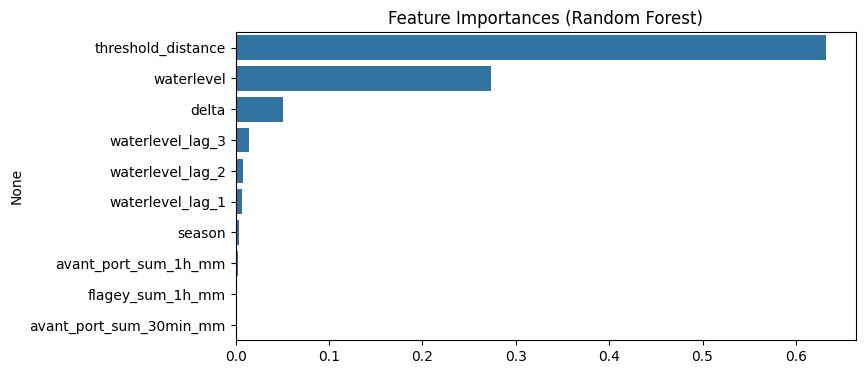

In [94]:
# Create and fit the model
rf = RandomForestRegressor(random_state=random_state)
rf.fit(X_train, y_train)

# Retrieve feature importances thourgh the feature_importances_ attribute
importances = rf.feature_importances_

# Print the top 10 features
indices = np.argsort(importances)[::-1]
print('Top 10 features by importance:')
for f in range(10):
    print(f"{f + 1}. {X_train.columns[indices[f]]} ({importances[indices[f]]:.4f})")

# Plot feature importances
plt.figure(figsize=(8,4))
plt.title('Feature Importances (Random Forest)')
sns.barplot(x=importances[indices[:10]], y=X_train.columns[indices[:10]])
plt.show()

**NOTE** We run into a problem here: the fact that threshold distance has a huge importance of 0.6 means that we are likely creating a bias here and letting the model take the shortcut of threshold distance instead of learning the relationships with the other variables. We will remove threshold distance and redo.

In [95]:
X_train.columns

Index(['avant_port_mm', 'flagey_mm', 'delta_avant_port_mm', 'delta_flagey_mm',
       'avant_port_lag1_mm', 'flagey_lag1_mm', 'avant_port_lag2_mm',
       'flagey_lag2_mm', 'avant_port_sum_1h_mm', 'flagey_sum_1h_mm',
       'avant_port_sum_30min_mm', 'flagey_sum_30min_mm',
       'avant_port_sum_15min_mm', 'flagey_sum_15min_mm',
       'avant_port_intensity_15min_mm', 'flagey_intensity_15min_mm',
       'avant_port_intensity_1h_mm', 'flagey_intensity_1h_mm',
       'avant_port_intensity_1d_mm', 'flagey_intensity_1d_mm', 'season',
       'waterlevel', 'delta', 'waterlevel_lag_1', 'waterlevel_lag_2',
       'waterlevel_lag_3', 'threshold_distance'],
      dtype='str')

In [96]:
# TODO here we want to remove threshold distance
X_train = X_train.drop(columns=['threshold_distance'])
X_val = X_val.drop(columns=['threshold_distance'])
X_trainval = X_trainval.drop(columns=['threshold_distance'])
X_test = X_test.drop(columns=['threshold_distance'])

NameError: name 'X_trainval' is not defined

In [ ]:
# drop the columns that are not in the 10 best
best_columns=X_train.columns[indices[:10]]
X_train = df_train[best_columns]
X_val = df_val[best_columns]
X_test_best = df_test[best_columns]

print(X_train.columns)

##Train RandomForestRegressor
Here we will train on the training set, but use RandomizedSearchCV with internal cross-validation.

In [ ]:

# Create a Random Forest pipeline with RandomizedSearchCV
rf_pipe = Pipeline([
    #selector has been done previously
    #scaling is not needed in RandomForests
    ('regressor', RandomForestRegressor(random_state=random_state))
])
# Define parameter distribution for RandomizedSearchCV
param_dist_rf = {
    'regressor__n_estimators': randint(50, 100),
    'regressor__max_depth': [3, 5, 7, 10],
    'regressor__min_samples_split': randint(2, 11),
    'regressor__min_samples_leaf': [1, 2, 4]
}
# Perform Randomized Search with cross-validation (cv)
rf_random_search = RandomizedSearchCV(rf_pipe,
                                      param_distributions=param_dist_rf,
                                      n_iter=20,
                                      cv=3,
                                      scoring='r2',
                                      random_state=random_state,
                                      n_jobs=4)
rf_random_search.fit(X_train, y_train)

# Print best parameters and best cross-validation score
print('Best parameters (RF):', rf_random_search.best_params_)
print('Best cross-val accuracy (RF):', round(rf_random_search.best_score_, 4))

##Train a linear model

In [ ]:

# Create a Random Forest pipeline with RandomizedSearchCV
lr_pipe = Pipeline([
    ('scaler', StandardScaler()), #maybe we have to take a different one bc of many outliers?
    ('regressor', LinearRegression())
])

lr_pipe.fit(X_train, y_train)

scores = cross_val_score(lr_pipe, X_train, y_train, cv=3, scoring='r2')
print('Cross-val R2 (LR):', scores)

In [ ]:
# select the best estimator from the random search for RF
best_rf = rf_random_search.best_estimator_

# predict on validation set
y_val_pred_rf = best_rf.predict(X_val)
y_val_pred_lr = lr_pipe.predict(X_val)

# check how the models score on the validation test
print('\nRandom Forest:\n')
print('Validation MSE (RF):', round(mean_squared_error(y_val, y_val_pred_rf),4))
print('Validation RMSE (RF):', round(np.sqrt(mean_squared_error(y_val, y_val_pred_rf)),4))
print('Validation MAE (RF):', round(mean_absolute_error(y_val, y_val_pred_rf),4))
print('Validation R2 (RF):', round(r2_score(y_val, y_val_pred_rf),4))
print('\nLinear Regression:\n')
print('Validation MSE (LR):', round(mean_squared_error(y_val, y_val_pred_lr),4))
print('Validation RMSE (LR):', round(np.sqrt(mean_squared_error(y_val, y_val_pred_lr)),4))
print('Validation MAE (LR):', round(mean_absolute_error(y_val, y_val_pred_lr),4))
print('Validation R2 (LR):', round(r2_score(y_val, y_val_pred_lr),4))


NOTE: @Sina

We will need to adjust the train-val-test split, since for the ANN, we use train_val in one with cross validation and for the others, we split train_val into train and val and then still do cross validation with the train set.

TODO:
- check train, val, test split and make it the same across models
- interpolate the few values we can (3 negative values)
- test on test set
- classify based on the best model
- t+15 model

In [ ]:
def classify(series):
    df = series.to_frame()
    df['classification'] = np.where(df['target'] > 3000, 'overflow', 'not overflow')
    return df

In [ ]:
df_test_class = classify(y_test)

In [ ]:
y_test_best_pred_lr = lr_pipe.predict(X_test_best)

In [ ]:
df_test_pred_class = classify(pd.Series(y_test_best_pred_lr, name='target'))

In [ ]:
y_test_class = df_test_class['classification']
y_test_pred_class = df_test_pred_class['classification']

In [ ]:
accuracy = accuracy_score(y_test_class, y_test_pred_class)
precision = precision_score(y_test_class, y_test_pred_class, average="macro")  
recall = recall_score(y_test_class, y_test_pred_class, average="macro")
f1 = f1_score(y_test_class, y_test_pred_class, average="macro")

cm = confusion_matrix(y_test_class, y_test_pred_class)
report = classification_report(y_test_class, y_test_pred_class)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", report)
not_overflow_ratio = df_test_class['classification'].value_counts()['not overflow'] / df_test_class['classification'].count()
overflow_ratio = df_test_class['classification'].value_counts()['overflow'] / df_test_class['classification'].count()
print(f"\n Class imbalance: \n not overflow ratio: {not_overflow_ratio}\n overflow ratio: {overflow_ratio}")

# References

Shakil, A., Khalighi, M. A., Pudlo, P., Leclerc, C., Laplace, D., Hamon, F., & Boudonne, A. (2023). Outlier detection in non-stationary time series applied to sewer network monitoring. Internet of Things, 21, 100654.
